<a href="https://colab.research.google.com/github/diyayourfav/AI-MLModule/blob/main/Worksheet3_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Modeling the Neuron: From MCP to Perceptron, Its Learning Algorithm, and Limitations.**

**Task - 1: Implementation of MCP Neurons:**

1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two
inputs:
Hint:

    • Aggregate all the inputs.

    • Handcraft a Threshold values for ”AND” and ”OR” Function.

    • Implement a if else statement as stated above.

    You may use code base provided below or write your own code from scratch:

AND Function using MCP Neuron

In [21]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []  # To store outputs

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold for AND

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate: {result}")

Output of AND gate: [0, 0, 0, 1]


OR Function using MCP Neuron

In [22]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []  # To store outputs

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold for OR

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate: {result_or}")

Output of OR gate: [0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons.

Ans:


*    Able to solve only linearly separable problems.

*   Unable to resolve non-linear problems such as XOR problems.


*   Uses fixed weights and threshold (no learning capability)

*   Unable to process complex patterns.




Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.

{Can you devise a if else rules.}

Ans: A single MCP neuron cannot solve the XOR function because it is not linearly separable. XOR outputs 1 when the inputs are different and 0 when they are the same. This cannot be handled by one threshold rule, so multiple neurons are required.

**Task 2: Perceptron Algorithm for 0 vs 1 Classification.**

In [23]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Ai_Ml/Data/Week3/mnist_0_and_1.csv")
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. What does the shape of X represent?

The shape (12665, 784) means there are 12,665 images and each image is represented by 784 pixel features.

2. What does the shape of Y represent?

The shape (12665,) means there are 12,665 labels, one label for each image.

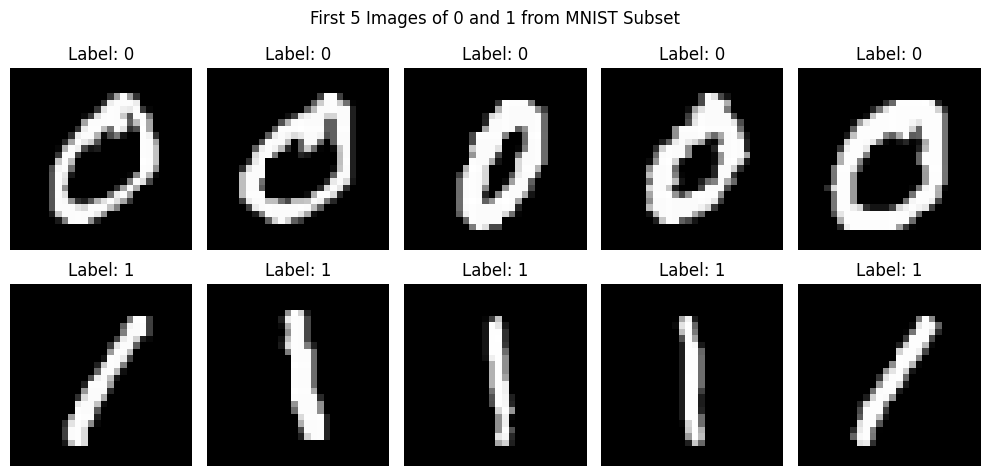

In [25]:
import matplotlib.pyplot as plt

# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Images with label 0
images_1 = X[y == 1]  # Images with label 1

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if enough images are available
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

# Title and display
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

**Initialization of the Weights:**

In [26]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question - 3: What does the weights array represent in this context?

Ans: The weights array represents the importance of each pixel (feature) in determining whether the image is digit 0 or 1.

Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

Ans: Weights are initialized to zero to start the model without any bias toward any feature. During training, the weights will be updated based on the data. However, starting with zeros can sometimes slow down learning or make all features initially treated equally.

**Implementation Decision Function:**

In [27]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """

    # Linear combination
    predictions = np.dot(X, weights) + bias

    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

*  np.dot(X, weights) + bias → computes raw scores
*  np.where(predictions >= 0, 1, 0) → converts them into class labels (0 or 1)




**Training the Perceptron:**

In [28]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """

    for _ in range(epochs):
        for i in range(len(X)):

            # Step 1: Compute output (linear combination)
            output = np.dot(X[i], weights) + bias

            # Step 2: Apply step function
            y_pred = 1 if output >= 0 else 0

            # Step 3: Update if prediction is wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    # Step 4: Calculate accuracy
    predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.mean(predictions == y)

    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Ans: This line calculates the weighted sum of inputs plus bias.

*   It determines how strongly the input features influence the prediction.

*   This value is then passed into the activation (step function) to decide the class (0 or 1).



**Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?**

Ans: The model updates weights and bias to reduce future errors.

**Question - 7:Why is the final accuracy important, and what do you expect it to be?**

Ans: Accuracy tells us how well our model learned from the data.

-It measures the percentage of correctly classified samples.

-Helps evaluate if training was successful.

If the data is linearly separable, accuracy should be close to 100%.
If not, accuracy may be lower because perceptron can’t handle complex boundaries

**Training the Perceptron Algorithm:**

In [29]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


**Visualizing Misclassified Image.**

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show up to 10
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.tight_layout()
    plt.show()

else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question - 8:What does misclassified idx store, and how is it used in this code?**

Ans: It stores the indices of all incorrectly predicted data points.

These indices are used to select and display misclassified images:

**Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?**

Ans: The model achieved 100% accuracy.
The dataset is likely linearly separable and
the perceptron successfully learned the pattern.

**Task 3: Perceptron Algorithm for 3 vs 5 Classification.**

Final Accuracy: 0.9632


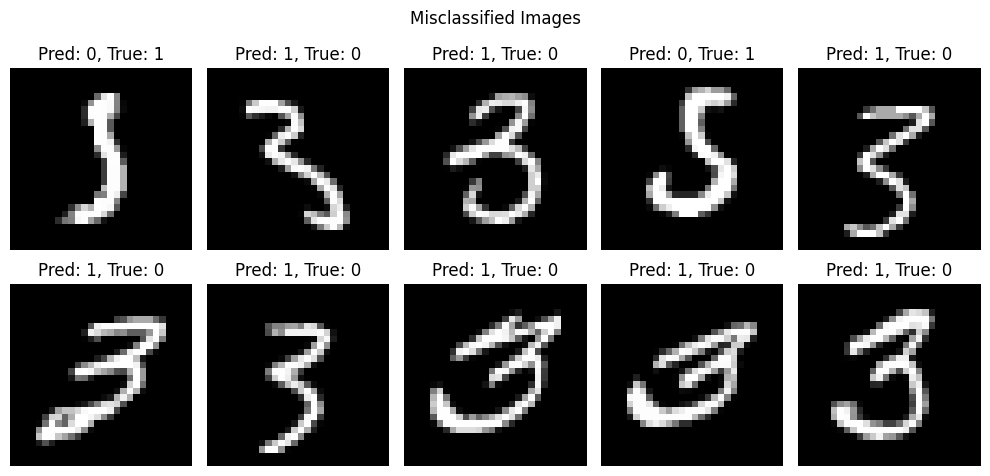

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/content/drive/MyDrive/Ai_Ml/Data/Week3/mnist_3_and_5.csv")

# First column = label, rest = pixels
y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values

# Normalize pixel values (0–255 → 0–1)
X = X / 255.0

# Convert labels: 3 → 0, 5 → 1
y = np.where(y == 5, 1, 0)

np.random.seed(42)
weights = np.zeros(X.shape[1])
bias = 0

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10):
    for _ in range(epochs):
        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate * (y[i] - y_pred)

    return weights, bias

weights, bias = train_perceptron(X, y, weights, bias)

predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis('off')

    plt.suptitle("Misclassified Images")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

**Conclusion**

The Perceptron successfully classified digits 3 and 5 with good accuracy. Misclassifications occurred due to similarities in digit shapes and data complexity, showing the limitation of linear models.